In [6]:
import numpy as np
import scipy.constants as sci_const
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'grid', 'notebook'])

import sys
sys.path.append('../../../')
%load_ext autoreload
%autoreload 2

import miepython
from mores.misc.lunar_rocks_psd import lunar_psd_vol, lunar_psd_area, LunarRocksPSD
from mores.layer.miepython_utils import mie_cross_sections, mie_cross_sections_psd, mie_phase_matrix_Csca

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from plot_utils import label_subplot_abc

In [8]:
# INPUT

# Default and derived
out_fig_dir = r"E:\zhaofei\tasks\PhD\thesis\draft_v2\chap3\chap3_figures\figures"

In [9]:
epsr_particle = 6.0 * (1 - 0.03j)
epsr1 = 2.7 * (1 - 0.007j)
epsr = epsr_particle/ np.real(epsr1)
m = np.sqrt(epsr)
wavelength = 12.6e-2
RA = np.linspace(0.001*1e-2, 1e-2, 20)

ke = np.zeros(len(RA))
ks = np.zeros(len(RA))
ssa = np.zeros(len(RA))

for i in range(len(RA)):
    psd_obj = LunarRocksPSD(k=RA[i])
    # Cext, Csca, Cback = mie_cross_sections_psd(m, wavelength, psd_obj.lunar_psd_vol, Dmin=None, Dmax=10e-2)
    Cext, Csca, Cback = mie_cross_sections_psd(m, wavelength, psd_obj.lunar_psd_vol, Dmin=None, Dmax=psd_obj.Dmax)        
    # print(f"Cext: {Cext}, Csca: {Csca}, Cback: {Cback}, ssa: {Csca/Cext}")
    ke[i] = Cext
    ks[i] = Csca
    ssa[i] = ks[i] / ke[i]

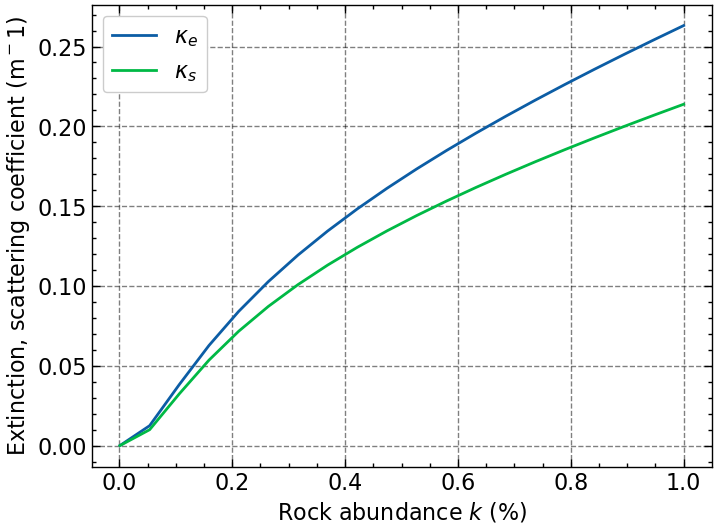

In [10]:
RA100 = RA*100
fig, ax = plt.subplots(1, 1)
ax.plot(RA100, ke, label=r'$\kappa_e$')
ax.plot(RA100, ks, label=r'$\kappa_s$')
ax.set_xlabel(r'Rock abundance $k$ (%)')
ax.set_ylabel(r'Extinction, scattering coefficient (m$^-1$)')
ax.legend()

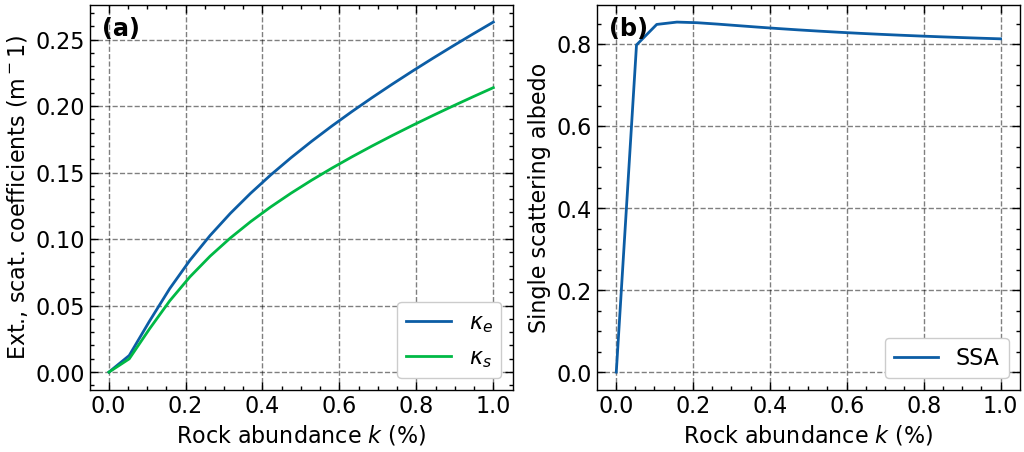

In [11]:
# show both rock abundance and ssa
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(RA100, ke, label=r'$\kappa_e$')
ax[0].plot(RA100, ks, label=r'$\kappa_s$')
ax[0].set_xlabel(r'Rock abundance $k$ (%)')
ax[0].set_ylabel(r'Ext., scat. coefficients (m$^-1$)')
ax[0].legend()
ax[1].plot(RA100, ssa, label='SSA')
ax[1].set_xlabel(r'Rock abundance $k$ (%)')
ax[1].set_ylabel(r'Single scattering albedo')
ax[1].legend()
for i in range(2):
    label_subplot_abc(ax[i], i)
fig.savefig(out_fig_dir + "/ke_ks_vs_rock_abundance.pdf")